Import and Clean data

In [1]:
#install dependencies
#!pip uninstall pandas -y
#!pip install pandas --upgrade

In [9]:
import pandas as pd
import numpy as np
import os

# Load Iyer data
os.chdir("/content/drive/MyDrive/Colab Notebooks/Final")
print(os.getcwd())
df = pd.read_csv("IYER/SVM/data/iyer.txt", sep="\t", header=None)

# Drop outliers (label = -1)
df = df[df[1] != -1]

# Split into features and labels
X = df.iloc[:, 2:].values  # gene expression values
y = df.iloc[:, 1].values   # cluster labels

/content/drive/MyDrive/Colab Notebooks/Final


# Standardize Features

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Train the model using the best parameters (hyperparameter)

In [11]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

svc = SVC(probability=True)
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear']
}

grid = GridSearchCV(svc, param_grid, cv=skf, scoring='accuracy')
grid.fit(X_scaled, y)

print("Best Parameters:", grid.best_params_)
best_model = grid.best_estimator_

Best Parameters: {'C': 1, 'kernel': 'linear'}


# Create a model with no tuning

In [12]:
from sklearn.svm import SVC

# Fixed model with no tuning
fixed_model = SVC(C=1, kernel='linear', probability=True)

accs_base, f1s_base, aucs_base = [], [], []
classes = np.unique(y)

for i in range(3):
    for train_idx, test_idx in skf.split(X_scaled, y):
        X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        fixed_model.fit(X_train, y_train)
        y_pred = fixed_model.predict(X_test)
        y_prob = fixed_model.predict_proba(X_test)

        accs_base.append(accuracy_score(y_test, y_pred))
        f1s_base.append(f1_score(y_test, y_pred, average='macro'))
        y_bin = label_binarize(y_test, classes=classes)
        aucs_base.append(roc_auc_score(y_bin, y_prob, average='macro', multi_class='ovr'))

print("🔹 Base (No Tuning)")
print(f"Accuracy: {np.mean(accs_base):.4f} ± {np.std(accs_base):.4f}")
print(f"F1 Score: {np.mean(f1s_base):.4f} ± {np.std(f1s_base):.4f}")
print(f"AUC: {np.mean(aucs_base):.4f} ± {np.std(aucs_base):.4f}")


🔹 Base (No Tuning)
Accuracy: 0.8409 ± 0.0167
F1 Score: 0.7785 ± 0.0368
AUC: 0.9746 ± 0.0102


# Evaluate Metrics of tuned model


In [13]:
accs, f1s, aucs = [], [], []
classes = np.unique(y)

for i in range(3):
    for train_idx, test_idx in skf.split(X_scaled, y):
        X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        best_model.fit(X_train, y_train)
        y_pred = best_model.predict(X_test)
        y_prob = best_model.predict_proba(X_test)

        accs.append(accuracy_score(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred, average='macro'))
        y_bin = label_binarize(y_test, classes=classes)
        aucs.append(roc_auc_score(y_bin, y_prob, average='macro', multi_class='ovr'))

print(f"Accuracy: {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"F1 Score: {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
print(f"AUC: {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")


Accuracy: 0.8409 ± 0.0167
F1 Score: 0.7785 ± 0.0368
AUC: 0.9751 ± 0.0093


# Sensitivity Analysis

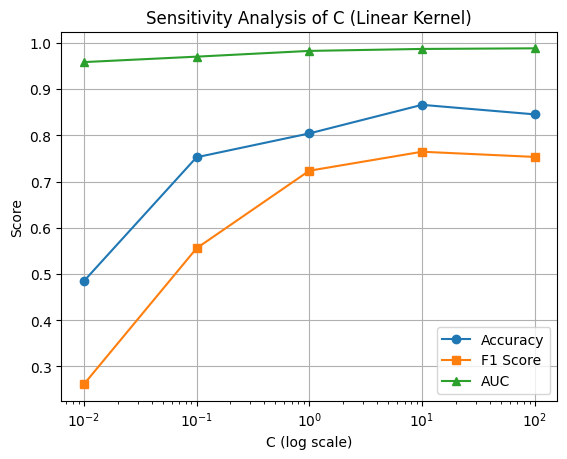

In [14]:
import matplotlib.pyplot as plt

C_values = [0.01, 0.1, 1, 10, 100]
accs, f1s, aucs = [], [], []

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

for C in C_values:
    model = SVC(C=C, kernel='linear', probability=True)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    accs.append(accuracy_score(y_test, y_pred))
    f1s.append(f1_score(y_test, y_pred, average='macro'))
    aucs.append(roc_auc_score(y_test_bin, y_prob, average='macro', multi_class='ovr'))

# Plot results
plt.plot(C_values, accs, marker='o', label='Accuracy')
plt.plot(C_values, f1s, marker='s', label='F1 Score')
plt.plot(C_values, aucs, marker='^', label='AUC')
plt.xscale('log')
plt.xlabel("C (log scale)")
plt.ylabel("Score")
plt.title("Sensitivity Analysis of C (Linear Kernel)")
plt.legend()
plt.grid(True)
plt.show()
